# Progetto 1

### Obiettivo del Progetto

L'obiettivo è esplorare due metodologie distinte (DBSCAN e Elbow Method tramite Inertia/WCSS) per determinare il numero ottimale di cluster $K$ su un dataset non etichettato. Successivamente, si applicherà l'algoritmo K-Means utilizzando il valore di $K$ identificato. Per questo esercizio verrà utilizzato il dataset Iris, ignorando le etichette di classe originali.

***

### 1. Data Exploration & Preprocessing

  - Caricamento e Analisi: Caricare il dataset e fornire un'analisi descrittiva iniziale (es. df.describe()).
  - Standardizzazione: Applicare la standardizzazione alle feature ($X$) per garantire che tutti gli attributi abbiano media zero e deviazione standard unitaria.

### 2. Stima di $K$ con DBSCAN

Eseguire l'algoritmo DBSCAN iterativamente per analizzare la struttura dei dati basata sulla densità.

  Parametri di Iterazione:
  - $min_samples = 5$
  - $eps in [0.35, 0.45, 0.55]$
  
  Metriche da determinare per ogni esecuzione:
  - Il numero di cluster $K$ identificati.
  - Il numero di punti rumorosi (label -1).
  - Selezione: Individuare il numero di cluster $K$ più plausibile tra i risultati ottenuti.

### 3. Stima di $K$ con Elbow Method
Utilizzare K-Means per identificare il $K$ ottimale analizzando l'inerzia (o WCSS: Within Cluster Sum of Squares).

  - Configurazione:Algoritmo: K-Means.Range di $K$: da 1 a 10.
  - Algoritmo: K-Means.
  - Range di $K$: da 1 a 10.
  - Visualizzazione:Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e $K$ sull'asse X).Identificazione del "punto di gomito" (dove la curva si piega).Inserimento di un asse verticale in corrispondenza del valore $x = K$ scelto.
  - Plot del grafico dell'Elbow Method (Inerzia sull'asse Y e $K$ sull'asse X).
  - Identificazione del "punto di gomito" (dove la curva si piega).
  - Inserimento di un asse verticale in corrispondenza del valore $x = K$ scelto.

### 4. Applicazione Finale & Visualizzazione

  - Clusterizzazione Definitiva: Stabilire il $K$ finale e applicare il K-Means sul dataset standardizzato.
  - Valutazione: Calcolare il Silhouette Score per valutare la coesione interna e la separazione dei cluster.
  - Visualizzazione Risultati:Plot dei dati proiettati in 2D (utilizzando le prime due feature).+1Rappresentazione dei centroidi dei cluster.
  - Plot dei dati proiettati in 2D (utilizzando le prime due feature).+1
  - Rappresentazione dei centroidi dei cluster.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

### 1. Data Exploration & Preprocessing

In [34]:
# Caricamento dataset
iris = load_iris()

# Creazione DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [35]:
# Analisi descrittiva
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [36]:
# Controllo valori mancanti
df.isnull().sum()

# Separazione delle feature
X = df.copy()

# Standardizzazione
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


### 2. Stima di K con DBSCAN

In [54]:
eps_values = [0.35, 0.45, 0.55]
min_samples = 5

results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)

    # Numero di cluster (escludendo il rumore -1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Numero di punti rumorosi
    noise_points = list(labels).count(-1)

    results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": noise_points
    })

# Convertiamo in DataFrame per leggibilità
results_df = pd.DataFrame(results)
results_df

,eps,clusters,noise_points
0,0.35,4,104
1,0.45,3,54
2,0.55,2,29


### 3. Stima di K con Elbow Method

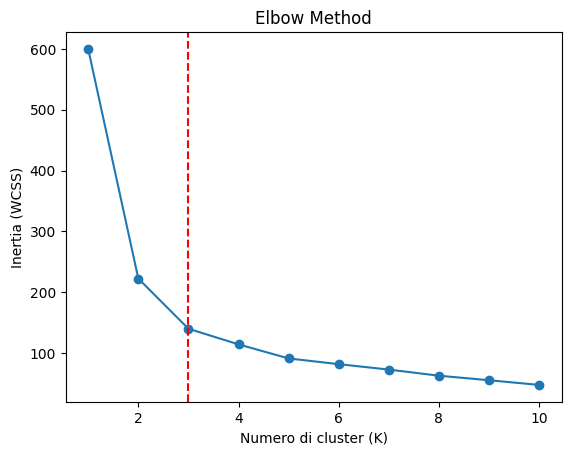

In [38]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Grafico Elbow Method
plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Numero di cluster (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')

# Inseriamo la linea verticale sul K scelto
plt.axvline(x=3, color='r', linestyle='--')

plt.show()

### 4. Clustering Finale con K-Means

In [39]:
K_final = 3

kmeans = KMeans(n_clusters=K_final, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

centroids = kmeans.cluster_centers_

### 5. Silhouette Score

In [40]:
score = silhouette_score(X_scaled, labels)
print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.460


### 6. Visualizzazione finale

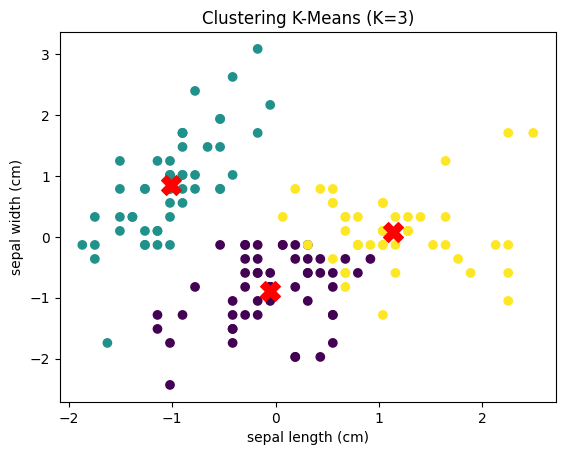

In [52]:
plt.figure()

plt.scatter(X_scaled.iloc[:, 0], X_scaled.iloc[:, 1], c=labels)

# Centroidi
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', color='red', s=200)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])
plt.title("Clustering K-Means (K=3)")

plt.show()

### 7. Visualizzazione con PCA (EXTRA)

In [42]:
from sklearn.decomposition import PCA

Aggiungi PCA per visualizzazione

In [43]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [45]:
# Trasformazione centroidi
original_columns = X_scaled.columns
centroids_df = pd.DataFrame(centroids, columns=original_columns)
centroids_pca = pca.transform(centroids_df)

Plot finale

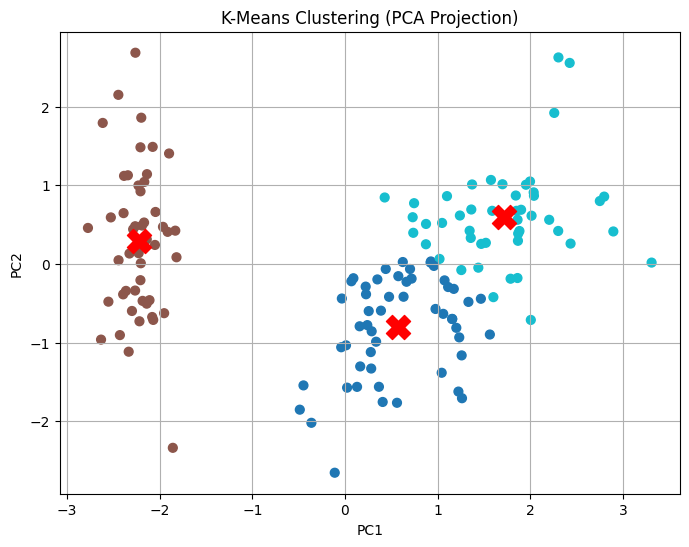

In [49]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    cmap='tab10',
    s=40
)

plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    marker='X',
    color='red',
    s=300
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering (PCA Projection)")

plt.grid()
plt.show()